# Enterprise Operational Data Warehouse & Analytics Pipeline

**Kaggle end-to-end portfolio project**

This notebook builds a complete operational-data pipeline using **Python, PySpark, Data Quality checks, dimensional modelling, a Star Schema, Spark SQL analytics, and management-ready visualisations**.

The data are **100% synthetic**. No confidential or real operational records are used.

### Business scenario
A large technical organisation operates equipment, computer systems, networks, maintenance teams, spare-parts inventory, and procurement processes. The goal is to turn raw operational records into a clean analytical warehouse that supports management decisions.

### Pipeline
`Synthetic Raw Data → PySpark ETL → Data Quality Validation → Clean Data → Star Schema → Spark SQL Analytics → KPI Charts → Exported Warehouse`

### What you will learn
- Operational data handling
- Data quality and validation
- ETL concepts
- PySpark transformations
- Data warehousing
- Fact and dimension tables
- Star schema / dimensional modelling
- SQL analytics
- KPI reporting

## 1. Install the required packages

Kaggle already includes many Python libraries. We install **PySpark** and **Faker** to make the notebook fully reproducible.

In [3]:
!pip -q install pyspark faker

## 2. Imports and project folders

All generated files will be written under `/kaggle/working/enterprise_operational_data_warehouse` so they appear in the Kaggle notebook output after execution.

In [4]:
import os
import random
from datetime import timedelta, date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType, DoubleType

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
Faker.seed(SEED)
fake = Faker()

BASE_DIR = "/kaggle/working/enterprise_operational_data_warehouse"
RAW_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")
WAREHOUSE_DIR = os.path.join(BASE_DIR, "warehouse")
REPORT_DIR = os.path.join(BASE_DIR, "reports")

for folder in [RAW_DIR, PROCESSED_DIR, WAREHOUSE_DIR, REPORT_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Project folders created:")
for folder in [RAW_DIR, PROCESSED_DIR, WAREHOUSE_DIR, REPORT_DIR]:
    print(" -", folder)

Project folders created:
 - /kaggle/working/enterprise_operational_data_warehouse/data/raw
 - /kaggle/working/enterprise_operational_data_warehouse/data/processed
 - /kaggle/working/enterprise_operational_data_warehouse/warehouse
 - /kaggle/working/enterprise_operational_data_warehouse/reports


## 3. Generate synthetic operational datasets

We generate seven connected datasets that represent the same types of operational information found in large technical organisations:

1. Equipment / asset master data
2. Personnel / resource data
3. Maintenance records
4. Incident and failure records
5. System-performance logs
6. Inventory / spare-parts data
7. Procurement data

A few **intentional data-quality problems** are inserted so the validation pipeline has real issues to detect.

In [5]:
# -----------------------------
# Equipment
# -----------------------------
equipment_types = [
    "Communication System", "Computer Server", "Network Device",
    "Monitoring System", "Power Unit", "Control System"
]
locations = ["Site A", "Site B", "Site C", "Site D"]
equipment_statuses = ["Operational", "Under Maintenance", "Out of Service"]

equipment_records = []
for i in range(1, 1001):
    equipment_records.append({
        "equipment_id": f"EQ{i:04d}",
        "equipment_type": random.choice(equipment_types),
        "location": random.choice(locations),
        "status": random.choice(equipment_statuses),
        "commission_date": fake.date_between(start_date="-10y", end_date="-1y")
    })
equipment_df = pd.DataFrame(equipment_records)
equipment_df.loc[10, "equipment_id"] = None          # missing key
quipment_bad_status_idx = 25
equipment_df.loc[quipment_bad_status_idx, "status"] = None
# duplicate row
equipment_df = pd.concat([equipment_df, equipment_df.iloc[[50]]], ignore_index=True)

# -----------------------------
# Personnel
# -----------------------------
specializations = [
    "Network Engineer", "Systems Engineer", "Maintenance Engineer",
    "Data Analyst", "Technician", "Operations Specialist"
]
personnel_records = []
for i in range(1, 301):
    personnel_records.append({
        "personnel_id": f"P{i:04d}",
        "name": fake.name(),
        "specialization": random.choice(specializations),
        "team": f"Team {random.randint(1, 10)}",
        "location": random.choice(locations),
        "years_experience": random.randint(1, 25)
    })
personnel_df = pd.DataFrame(personnel_records)

# -----------------------------
# Maintenance
# -----------------------------
maintenance_types = ["Preventive", "Corrective", "Emergency", "Inspection"]
maintenance_records = []
for i in range(1, 5001):
    maintenance_records.append({
        "maintenance_id": f"M{i:05d}",
        "equipment_id": f"EQ{random.randint(1, 1000):04d}",
        "personnel_id": f"P{random.randint(1, 300):04d}",
        "maintenance_date": fake.date_between(start_date="-3y", end_date="today"),
        "maintenance_type": random.choice(maintenance_types),
        "maintenance_cost": round(random.uniform(200, 15000), 2),
        "downtime_hours": round(random.uniform(0.5, 48), 2)
    })
maintenance_df = pd.DataFrame(maintenance_records)
maintenance_df.loc[15, "equipment_id"] = None       # missing FK
maintenance_df.loc[20, "maintenance_cost"] = -500   # invalid cost
maintenance_df = pd.concat([maintenance_df, maintenance_df.iloc[[100]]], ignore_index=True)

# -----------------------------
# Incidents / failures
# -----------------------------
failure_types = [
    "Network Failure", "Hardware Failure", "Software Error",
    "Power Failure", "Communication Loss", "Performance Degradation"
]
severity_levels = ["Low", "Medium", "High", "Critical"]
incident_records = []
for i in range(1, 3001):
    incident_records.append({
        "incident_id": f"INC{i:05d}",
        "equipment_id": f"EQ{random.randint(1, 1000):04d}",
        "incident_date": fake.date_between(start_date="-3y", end_date="today"),
        "failure_type": random.choice(failure_types),
        "severity": random.choice(severity_levels),
        "resolution_time_hours": round(random.uniform(0.5, 72), 2),
        "downtime_hours": round(random.uniform(0.1, 48), 2)
    })
incidents_df = pd.DataFrame(incident_records)
incidents_df.loc[30, "equipment_id"] = "EQ9999"     # invalid FK

# -----------------------------
# System-performance logs
# -----------------------------
system_logs = []
for i in range(1, 10001):
    system_logs.append({
        "log_id": f"LOG{i:06d}",
        "equipment_id": f"EQ{random.randint(1, 1000):04d}",
        "timestamp": fake.date_time_between(start_date="-1y", end_date="now"),
        "cpu_usage_percent": round(random.uniform(5, 100), 2),
        "memory_usage_percent": round(random.uniform(10, 100), 2),
        "availability_percent": round(random.uniform(90, 100), 3),
        "alerts_count": random.randint(0, 20)
    })
system_logs_df = pd.DataFrame(system_logs)
system_logs_df.loc[40, "availability_percent"] = 150  # invalid percentage

# -----------------------------
# Inventory
# -----------------------------
part_categories = [
    "Network Parts", "Server Components", "Power Components",
    "Communication Parts", "Cables", "Electronic Components"
]
inventory_records = []
for i in range(1, 501):
    inventory_records.append({
        "part_id": f"PART{i:04d}",
        "part_name": f"Spare Part {i}",
        "category": random.choice(part_categories),
        "quantity_in_stock": random.randint(0, 500),
        "reorder_level": random.randint(10, 100),
        "unit_cost": round(random.uniform(10, 5000), 2)
    })
inventory_df = pd.DataFrame(inventory_records)
inventory_df.loc[12, "quantity_in_stock"] = -10      # invalid stock

# -----------------------------
# Procurement
# -----------------------------
suppliers = ["Supplier A", "Supplier B", "Supplier C", "Supplier D", "Supplier E"]
procurement_records = []
for i in range(1, 2001):
    order_date = fake.date_between(start_date="-3y", end_date="-30d")
    delivery_days = random.randint(2, 60)
    delivery_date = (pd.Timestamp(order_date) + timedelta(days=delivery_days)).date()
    procurement_records.append({
        "procurement_id": f"PO{i:05d}",
        "part_id": f"PART{random.randint(1, 500):04d}",
        "supplier": random.choice(suppliers),
        "order_date": order_date,
        "delivery_date": delivery_date,
        "quantity_ordered": random.randint(1, 200),
        "unit_price": round(random.uniform(10, 5000), 2)
    })
procurement_df = pd.DataFrame(procurement_records)

# Save raw datasets
raw_datasets = {
    "equipment.csv": equipment_df,
    "personnel.csv": personnel_df,
    "maintenance.csv": maintenance_df,
    "incidents.csv": incidents_df,
    "system_logs.csv": system_logs_df,
    "inventory.csv": inventory_df,
    "procurement.csv": procurement_df
}

for filename, dataframe in raw_datasets.items():
    dataframe.to_csv(os.path.join(RAW_DIR, filename), index=False)

raw_counts = pd.DataFrame({
    "dataset": list(raw_datasets.keys()),
    "records": [len(df) for df in raw_datasets.values()]
})
raw_counts.loc[len(raw_counts)] = ["TOTAL", raw_counts["records"].sum()]
raw_counts

,dataset,records
0,equipment.csv,1001
1,personnel.csv,300
2,maintenance.csv,5001
3,incidents.csv,3000
4,system_logs.csv,10000
5,inventory.csv,500
6,procurement.csv,2000
7,TOTAL,21802


## 4. Start PySpark

PySpark gives us a scalable, distributed ETL engine. The current synthetic data are small enough for a notebook, but the same transformation logic can scale to much larger enterprise datasets.

In [6]:
spark = (
    SparkSession.builder
    .appName("EnterpriseOperationalDataWarehouse")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Spark session ready.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/10/06 23:36:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.4
Spark session ready.


## 5. Load raw CSV files with PySpark

In [7]:
def read_csv(name):
    return spark.read.option("header", True).option("inferSchema", True).csv(os.path.join(RAW_DIR, name))

sp_equipment = read_csv("equipment.csv")
sp_personnel = read_csv("personnel.csv")
sp_maintenance = read_csv("maintenance.csv")
sp_incidents = read_csv("incidents.csv")
sp_logs = read_csv("system_logs.csv")
sp_inventory = read_csv("inventory.csv")
sp_procurement = read_csv("procurement.csv")

print("Raw PySpark counts:")
for name, df in {
    "equipment": sp_equipment,
    "personnel": sp_personnel,
    "maintenance": sp_maintenance,
    "incidents": sp_incidents,
    "system_logs": sp_logs,
    "inventory": sp_inventory,
    "procurement": sp_procurement
}.items():
    print(f"{name:<15}: {df.count():>6}")

Raw PySpark counts:
equipment      :   1001
personnel      :    300
maintenance    :   5001
incidents      :   3000
system_logs    :  10000
inventory      :    500
procurement    :   2000


## 6. Data Quality Validation

The quality layer checks the most important problems before data are allowed into the warehouse.

Examples:
- Missing business keys
- Duplicate records
- Negative financial values
- Invalid foreign keys
- Invalid percentages
- Negative stock

In [8]:
valid_equipment_ids = sp_equipment.filter(F.col("equipment_id").isNotNull()).select("equipment_id").distinct()
valid_part_ids = sp_inventory.select("part_id").distinct()

quality_results = []

def add_check(dataset, rule, failed_count):
    quality_results.append({
        "dataset": dataset,
        "rule": rule,
        "failed_records": int(failed_count)
    })

# Equipment
add_check("equipment", "Missing equipment_id", sp_equipment.filter(F.col("equipment_id").isNull()).count())
add_check("equipment", "Missing status", sp_equipment.filter(F.col("status").isNull()).count())
add_check(
    "equipment", "Duplicate equipment_id",
    sp_equipment.groupBy("equipment_id").count().filter((F.col("equipment_id").isNotNull()) & (F.col("count") > 1)).count()
)

# Maintenance
add_check("maintenance", "Missing equipment_id", sp_maintenance.filter(F.col("equipment_id").isNull()).count())
add_check("maintenance", "Negative maintenance cost", sp_maintenance.filter(F.col("maintenance_cost") < 0).count())
add_check(
    "maintenance", "Duplicate maintenance_id",
    sp_maintenance.groupBy("maintenance_id").count().filter(F.col("count") > 1).count()
)
maintenance_invalid_fk = (
    sp_maintenance.filter(F.col("equipment_id").isNotNull())
    .join(valid_equipment_ids, "equipment_id", "left_anti")
    .count()
)
add_check("maintenance", "Invalid equipment foreign key", maintenance_invalid_fk)

# Incidents
incident_invalid_fk = sp_incidents.join(valid_equipment_ids, "equipment_id", "left_anti").count()
add_check("incidents", "Invalid equipment foreign key", incident_invalid_fk)

# System logs
add_check("system_logs", "Availability outside 0-100", sp_logs.filter((F.col("availability_percent") < 0) | (F.col("availability_percent") > 100)).count())

# Inventory
add_check("inventory", "Negative stock quantity", sp_inventory.filter(F.col("quantity_in_stock") < 0).count())

# Procurement
procurement_invalid_fk = sp_procurement.join(valid_part_ids, "part_id", "left_anti").count()
add_check("procurement", "Invalid part foreign key", procurement_invalid_fk)

quality_report = pd.DataFrame(quality_results)
quality_report["status"] = np.where(quality_report["failed_records"] == 0, "PASS", "FAIL")
quality_report.to_csv(os.path.join(REPORT_DIR, "data_quality_report.csv"), index=False)
quality_report

,dataset,rule,failed_records,status
0,equipment,Missing equipment_id,1,FAIL
1,equipment,Missing status,1,FAIL
2,equipment,Duplicate equipment_id,1,FAIL
3,maintenance,Missing equipment_id,1,FAIL
4,maintenance,Negative maintenance cost,1,FAIL
5,maintenance,Duplicate maintenance_id,1,FAIL
6,maintenance,Invalid equipment foreign key,6,FAIL
7,incidents,Invalid equipment foreign key,4,FAIL
8,system_logs,Availability outside 0-100,1,FAIL
9,inventory,Negative stock quantity,1,FAIL


In [9]:
print("Total failed quality checks/records:", quality_report["failed_records"].sum())
print("Rules passed:", (quality_report["status"] == "PASS").sum())
print("Rules with issues:", (quality_report["status"] == "FAIL").sum())

Total failed quality checks/records: 18
Rules passed: 1
Rules with issues: 10


## 7. Clean and transform the data

This is the ETL stage:

**Extract** raw CSV files → **Transform** invalid/duplicate records → **Load** clean datasets for warehouse modelling.

In [10]:
# Equipment
clean_equipment = (
    sp_equipment
    .filter(F.col("equipment_id").isNotNull())
    .dropDuplicates(["equipment_id"])
    .fillna({"status": "Unknown"})
    .withColumn("commission_date", F.to_date("commission_date"))
)

# Personnel
clean_personnel = sp_personnel.dropDuplicates(["personnel_id"])

# Maintenance
clean_maintenance = (
    sp_maintenance
    .filter(F.col("equipment_id").isNotNull())
    .filter(F.col("maintenance_cost") >= 0)
    .dropDuplicates(["maintenance_id"])
    .join(clean_equipment.select("equipment_id"), "equipment_id", "inner")
    .withColumn("maintenance_date", F.to_date("maintenance_date"))
)

# Incidents
clean_incidents = (
    sp_incidents
    .dropDuplicates(["incident_id"])
    .join(clean_equipment.select("equipment_id"), "equipment_id", "inner")
    .withColumn("incident_date", F.to_date("incident_date"))
)

# System logs
clean_logs = (
    sp_logs
    .dropDuplicates(["log_id"])
    .filter((F.col("availability_percent") >= 0) & (F.col("availability_percent") <= 100))
    .join(clean_equipment.select("equipment_id"), "equipment_id", "inner")
    .withColumn("timestamp", F.to_timestamp("timestamp"))
)

# Inventory
clean_inventory = (
    sp_inventory
    .dropDuplicates(["part_id"])
    .filter(F.col("quantity_in_stock") >= 0)
)

# Procurement
clean_procurement = (
    sp_procurement
    .dropDuplicates(["procurement_id"])
    .join(clean_inventory.select("part_id"), "part_id", "inner")
    .withColumn("order_date", F.to_date("order_date"))
    .withColumn("delivery_date", F.to_date("delivery_date"))
    .withColumn("delivery_days", F.datediff("delivery_date", "order_date"))
)

clean_datasets = {
    "equipment": clean_equipment,
    "personnel": clean_personnel,
    "maintenance": clean_maintenance,
    "incidents": clean_incidents,
    "system_logs": clean_logs,
    "inventory": clean_inventory,
    "procurement": clean_procurement
}

clean_counts = []
for name, df in clean_datasets.items():
    count = df.count()
    clean_counts.append((name, count))
    df.coalesce(1).write.mode("overwrite").option("header", True).csv(os.path.join(PROCESSED_DIR, name))

pd.DataFrame(clean_counts, columns=["dataset", "clean_records"])

,dataset,clean_records
0,equipment,999
1,personnel,300
2,maintenance,4992
3,incidents,2996
4,system_logs,9988
5,inventory,499
6,procurement,1999


## 8. Build the dimensional model (Star Schema)

A **Fact Table** stores measurable business events such as maintenance cost, downtime, incidents, or procurement quantities.

A **Dimension Table** provides descriptive context such as equipment, personnel, date, supplier, location, or spare part.

We create:

### Dimensions
- `DimEquipment`
- `DimPersonnel`
- `DimDate`
- `DimSupplier`
- `DimPart`

### Facts
- `FactMaintenance`
- `FactIncidents`
- `FactProcurement`
- `FactInventory`

In [11]:
# ---------- DimEquipment ----------
w_equipment = Window.orderBy("equipment_id")
dim_equipment = (
    clean_equipment
    .withColumn("equipment_key", F.row_number().over(w_equipment))
    .select(
        "equipment_key", "equipment_id", "equipment_type",
        "location", "status", "commission_date"
    )
)

# ---------- DimPersonnel ----------
w_personnel = Window.orderBy("personnel_id")
dim_personnel = (
    clean_personnel
    .withColumn("personnel_key", F.row_number().over(w_personnel))
    .select(
        "personnel_key", "personnel_id", "name", "specialization",
        "team", "location", "years_experience"
    )
)

# ---------- DimSupplier ----------
w_supplier = Window.orderBy("supplier")
dim_supplier = (
    clean_procurement.select("supplier").distinct()
    .withColumn("supplier_key", F.row_number().over(w_supplier))
    .select("supplier_key", "supplier")
)

# ---------- DimPart ----------
w_part = Window.orderBy("part_id")
dim_part = (
    clean_inventory
    .withColumn("part_key", F.row_number().over(w_part))
    .select("part_key", "part_id", "part_name", "category", "reorder_level")
)

# ---------- DimDate ----------
date_values = (
    clean_maintenance.select(F.col("maintenance_date").alias("full_date"))
    .union(clean_incidents.select(F.col("incident_date").alias("full_date")))
    .union(clean_procurement.select(F.col("order_date").alias("full_date")))
    .union(clean_procurement.select(F.col("delivery_date").alias("full_date")))
    .union(spark.createDataFrame([(date.today(),)], ["full_date"]))
    .filter(F.col("full_date").isNotNull())
    .distinct()
)

dim_date = (
    date_values
    .withColumn("date_key", F.date_format("full_date", "yyyyMMdd").cast(IntegerType()))
    .withColumn("day", F.dayofmonth("full_date"))
    .withColumn("month", F.month("full_date"))
    .withColumn("month_name", F.date_format("full_date", "MMMM"))
    .withColumn("quarter", F.quarter("full_date"))
    .withColumn("year", F.year("full_date"))
    .select("date_key", "full_date", "day", "month", "month_name", "quarter", "year")
)

print("Dimensions created:")
for name, df in {
    "DimEquipment": dim_equipment,
    "DimPersonnel": dim_personnel,
    "DimDate": dim_date,
    "DimSupplier": dim_supplier,
    "DimPart": dim_part
}.items():
    print(f"{name:<15}: {df.count():>6}")

Dimensions created:
DimEquipment   :    999
DimPersonnel   :    300


DimDate        :   1105
DimSupplier    :      5
DimPart        :    499


In [12]:
# ---------- FactMaintenance ----------
fact_maintenance = (
    clean_maintenance.alias("m")
    .join(dim_equipment.select("equipment_key", "equipment_id").alias("e"), "equipment_id")
    .join(dim_personnel.select("personnel_key", "personnel_id").alias("p"), "personnel_id")
    .join(dim_date.select("date_key", "full_date").alias("d"), F.col("m.maintenance_date") == F.col("d.full_date"))
    .select(
        "maintenance_id", "equipment_key", "personnel_key", "date_key",
        "maintenance_type", "maintenance_cost", "downtime_hours"
    )
)

# ---------- FactIncidents ----------
fact_incidents = (
    clean_incidents.alias("i")
    .join(dim_equipment.select("equipment_key", "equipment_id").alias("e"), "equipment_id")
    .join(dim_date.select("date_key", "full_date").alias("d"), F.col("i.incident_date") == F.col("d.full_date"))
    .select(
        "incident_id", "equipment_key", "date_key", "failure_type",
        "severity", "resolution_time_hours", "downtime_hours"
    )
)

# ---------- FactProcurement ----------
fact_procurement = (
    clean_procurement.alias("p")
    .join(dim_part.select("part_key", "part_id").alias("part"), "part_id")
    .join(dim_supplier.select("supplier_key", "supplier").alias("s"), "supplier")
    .join(
        dim_date.select(F.col("date_key").alias("order_date_key"), F.col("full_date").alias("order_full_date")).alias("od"),
        F.col("p.order_date") == F.col("od.order_full_date")
    )
    .join(
        dim_date.select(F.col("date_key").alias("delivery_date_key"), F.col("full_date").alias("delivery_full_date")).alias("dd"),
        F.col("p.delivery_date") == F.col("dd.delivery_full_date")
    )
    .select(
        "procurement_id", "part_key", "supplier_key", "order_date_key", "delivery_date_key",
        "quantity_ordered", "unit_price", "delivery_days"
    )
    .withColumn("total_order_value", F.round(F.col("quantity_ordered") * F.col("unit_price"), 2))
)

# ---------- FactInventory ----------
today_key = int(date.today().strftime("%Y%m%d"))
fact_inventory = (
    clean_inventory.alias("i")
    .join(dim_part.select("part_key", "part_id"), "part_id")
    .withColumn("snapshot_date_key", F.lit(today_key))
    .withColumn("reorder_flag", F.when(F.col("quantity_in_stock") <= F.col("reorder_level"), 1).otherwise(0))
    .select(
        "part_key", "snapshot_date_key", "quantity_in_stock",
        "reorder_level", "unit_cost", "reorder_flag"
    )
)

print("Fact tables created:")
for name, df in {
    "FactMaintenance": fact_maintenance,
    "FactIncidents": fact_incidents,
    "FactProcurement": fact_procurement,
    "FactInventory": fact_inventory
}.items():
    print(f"{name:<18}: {df.count():>6}")

Fact tables created:
FactMaintenance   :   4992
FactIncidents     :   2996
FactProcurement   :   1999
FactInventory     :    499


## 9. Save the warehouse tables as Parquet

Parquet is an efficient columnar format commonly used in analytical data platforms and data lakes.

In [13]:
warehouse_tables = {
    "dim_equipment": dim_equipment,
    "dim_personnel": dim_personnel,
    "dim_date": dim_date,
    "dim_supplier": dim_supplier,
    "dim_part": dim_part,
    "fact_maintenance": fact_maintenance,
    "fact_incidents": fact_incidents,
    "fact_procurement": fact_procurement,
    "fact_inventory": fact_inventory
}

for name, df in warehouse_tables.items():
    df.write.mode("overwrite").parquet(os.path.join(WAREHOUSE_DIR, name))

print(f"Saved {len(warehouse_tables)} warehouse tables to:")
print(WAREHOUSE_DIR)

26/10/06 23:37:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

Saved 9 warehouse tables to:
/kaggle/working/enterprise_operational_data_warehouse/warehouse


## 10. Register tables and run Spark SQL analytics

This section demonstrates SQL queries against the dimensional model.

In [14]:
for name, df in warehouse_tables.items():
    df.createOrReplaceTempView(name)

print("SQL views registered:", ", ".join(warehouse_tables.keys()))

SQL views registered: dim_equipment, dim_personnel, dim_date, dim_supplier, dim_part, fact_maintenance, fact_incidents, fact_procurement, fact_inventory


### Query 1 — Equipment with the highest number of incidents

In [15]:
top_failure_equipment = spark.sql("""
SELECT
    e.equipment_id,
    e.equipment_type,
    e.location,
    COUNT(*) AS failure_count,
    ROUND(SUM(f.downtime_hours), 2) AS total_incident_downtime
FROM fact_incidents f
JOIN dim_equipment e
    ON f.equipment_key = e.equipment_key
GROUP BY e.equipment_id, e.equipment_type, e.location
ORDER BY failure_count DESC, total_incident_downtime DESC
LIMIT 10
""")

top_failure_equipment.show(truncate=False)

26/10/06 23:37:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

+------------+--------------------+--------+-------------+-----------------------+
|equipment_id|equipment_type      |location|failure_count|total_incident_downtime|
+------------+--------------------+--------+-------------+-----------------------+
|EQ0077      |Power Unit          |Site B  |9            |234.39                 |
|EQ0427      |Control System      |Site B  |9            |233.22                 |
|EQ0615      |Network Device      |Site B  |9            |227.1                  |
|EQ0630      |Power Unit          |Site C  |9            |212.2                  |
|EQ0043      |Control System      |Site B  |9            |203.05                 |
|EQ0363      |Communication System|Site A  |9            |150.93                 |
|EQ0140      |Communication System|Site C  |8            |259.67                 |
|EQ0771      |Computer Server     |Site A  |8            |251.15                 |
|EQ0528      |Network Device      |Site B  |8            |242.74                 |
|EQ0

### Query 2 — Maintenance cost and downtime by equipment type

In [16]:
maintenance_by_type = spark.sql("""
SELECT
    e.equipment_type,
    COUNT(*) AS maintenance_events,
    ROUND(SUM(f.maintenance_cost), 2) AS total_maintenance_cost,
    ROUND(AVG(f.maintenance_cost), 2) AS avg_maintenance_cost,
    ROUND(SUM(f.downtime_hours), 2) AS total_downtime_hours
FROM fact_maintenance f
JOIN dim_equipment e
    ON f.equipment_key = e.equipment_key
GROUP BY e.equipment_type
ORDER BY total_maintenance_cost DESC
""")

maintenance_by_type.show(truncate=False)

26/10/06 23:37:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:22 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

+--------------------+------------------+----------------------+--------------------+--------------------+
|equipment_type      |maintenance_events|total_maintenance_cost|avg_maintenance_cost|total_downtime_hours|
+--------------------+------------------+----------------------+--------------------+--------------------+
|Power Unit          |960               |7369899.19            |7676.98             |23174.87            |
|Monitoring System   |881               |6555696.96            |7441.2              |20040.8             |
|Network Device      |817               |6227087.92            |7621.89             |19086.62            |
|Communication System|804               |6022838.81            |7491.09             |19998.88            |
|Control System      |776               |5835168.46            |7519.55             |19021.93            |
|Computer Server     |754               |5817041.98            |7714.91             |18173.88            |
+--------------------+---------------

### Query 3 — Incident severity profile

In [17]:
incident_severity = spark.sql("""
SELECT
    severity,
    COUNT(*) AS incident_count,
    ROUND(AVG(resolution_time_hours), 2) AS avg_resolution_hours,
    ROUND(SUM(downtime_hours), 2) AS total_downtime_hours
FROM fact_incidents
GROUP BY severity
ORDER BY incident_count DESC
""")

incident_severity.show(truncate=False)

+--------+--------------+--------------------+--------------------+
|severity|incident_count|avg_resolution_hours|total_downtime_hours|
+--------+--------------+--------------------+--------------------+
|High    |763           |35.92               |18764.45            |
|Critical|762           |35.98               |18784.39            |
|Medium  |751           |36.1                |17703.53            |
|Low     |720           |37.46               |17150.42            |
+--------+--------------+--------------------+--------------------+



### Query 4 — Supplier delivery performance

In [18]:
supplier_performance = spark.sql("""
SELECT
    s.supplier,
    COUNT(*) AS orders,
    ROUND(AVG(f.delivery_days), 2) AS avg_delivery_days,
    ROUND(SUM(f.total_order_value), 2) AS total_order_value
FROM fact_procurement f
JOIN dim_supplier s
    ON f.supplier_key = s.supplier_key
GROUP BY s.supplier
ORDER BY avg_delivery_days DESC
""")

supplier_performance.show(truncate=False)

26/10/06 23:37:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:25 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

+----------+------+-----------------+-----------------+
|supplier  |orders|avg_delivery_days|total_order_value|
+----------+------+-----------------+-----------------+
|Supplier E|406   |32.11            |9.681444892E7    |
|Supplier C|391   |31.3             |1.0134141073E8   |
|Supplier D|386   |30.95            |1.0051185864E8   |
|Supplier A|400   |30.62            |9.965254993E7    |
|Supplier B|416   |30.32            |1.037257619E8    |
+----------+------+-----------------+-----------------+



### Query 5 — Spare parts requiring reorder

In [19]:
reorder_parts = spark.sql("""
SELECT
    p.part_id,
    p.part_name,
    p.category,
    f.quantity_in_stock,
    f.reorder_level,
    f.unit_cost
FROM fact_inventory f
JOIN dim_part p
    ON f.part_key = p.part_key
WHERE f.reorder_flag = 1
ORDER BY f.quantity_in_stock ASC
""")

print("Parts requiring reorder:", reorder_parts.count())
reorder_parts.show(15, truncate=False)

26/10/06 23:37:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

Parts requiring reorder: 44


26/10/06 23:37:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

+--------+--------------+---------------------+-----------------+-------------+---------+
|part_id |part_name     |category             |quantity_in_stock|reorder_level|unit_cost|
+--------+--------------+---------------------+-----------------+-------------+---------+
|PART0308|Spare Part 308|Communication Parts  |2                |78           |3982.7   |
|PART0285|Spare Part 285|Server Components    |2                |76           |1799.53  |
|PART0136|Spare Part 136|Cables               |4                |34           |4711.6   |
|PART0458|Spare Part 458|Power Components     |5                |50           |4208.82  |
|PART0283|Spare Part 283|Cables               |6                |45           |2458.27  |
|PART0395|Spare Part 395|Communication Parts  |8                |78           |2412.71  |
|PART0053|Spare Part 53 |Network Parts        |9                |54           |1336.42  |
|PART0489|Spare Part 489|Network Parts        |9                |11           |503.95   |
|PART0346|

## 11. Management KPIs

In [20]:
kpis = {
    "Total Equipment": dim_equipment.count(),
    "Maintenance Events": fact_maintenance.count(),
    "Incidents": fact_incidents.count(),
    "Total Maintenance Cost": fact_maintenance.agg(F.round(F.sum("maintenance_cost"), 2)).first()[0],
    "Total Maintenance Downtime (hrs)": fact_maintenance.agg(F.round(F.sum("downtime_hours"), 2)).first()[0],
    "Average Incident Resolution (hrs)": fact_incidents.agg(F.round(F.avg("resolution_time_hours"), 2)).first()[0],
    "Parts Requiring Reorder": fact_inventory.filter(F.col("reorder_flag") == 1).count(),
    "Procurement Orders": fact_procurement.count()
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=["KPI", "Value"])
kpi_df

,KPI,Value
0,Total Equipment,999.00
1,Maintenance Events,4992.00
2,Incidents,2996.00
3,Total Maintenance Cost,37827733.32
4,Total Maintenance Downtime (hrs),119496.98
5,Average Incident Resolution (hrs),36.35
6,Parts Requiring Reorder,44.00
7,Procurement Orders,1999.00


## 12. Visual analytics

26/10/06 23:37:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

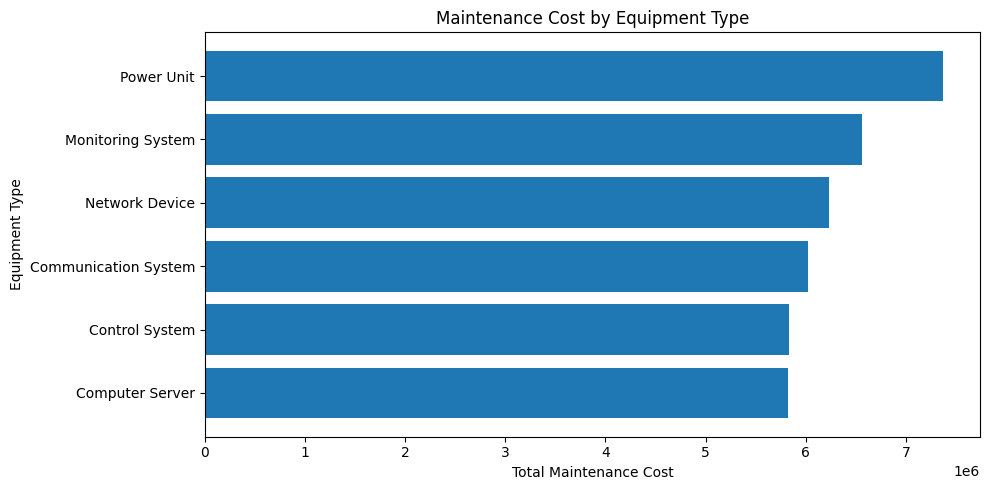

In [21]:
# Maintenance cost by equipment type
plot_df = maintenance_by_type.toPandas().sort_values("total_maintenance_cost", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["equipment_type"], plot_df["total_maintenance_cost"])
plt.xlabel("Total Maintenance Cost")
plt.ylabel("Equipment Type")
plt.title("Maintenance Cost by Equipment Type")
plt.tight_layout()
plt.show()

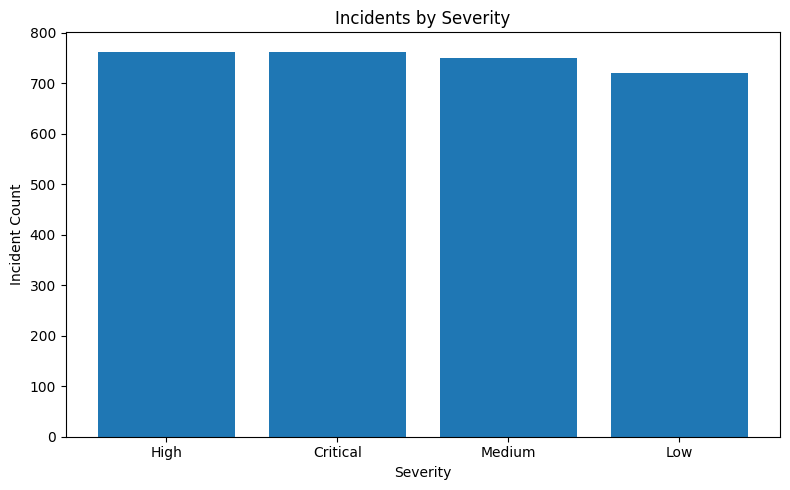

In [22]:
# Incidents by severity
severity_df = incident_severity.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(severity_df["severity"], severity_df["incident_count"])
plt.xlabel("Severity")
plt.ylabel("Incident Count")
plt.title("Incidents by Severity")
plt.tight_layout()
plt.show()

26/10/06 23:37:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

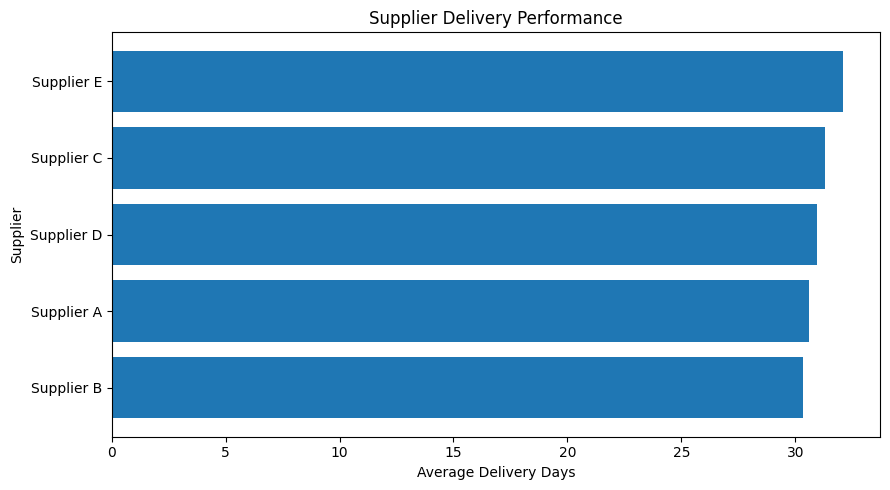

In [23]:
# Supplier delivery performance
supplier_df = supplier_performance.toPandas().sort_values("avg_delivery_days", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(supplier_df["supplier"], supplier_df["avg_delivery_days"])
plt.xlabel("Average Delivery Days")
plt.ylabel("Supplier")
plt.title("Supplier Delivery Performance")
plt.tight_layout()
plt.show()

## 13. Export final reports

In [24]:
# Export compact management outputs
kpi_df.to_csv(os.path.join(REPORT_DIR, "management_kpis.csv"), index=False)
top_failure_equipment.toPandas().to_csv(os.path.join(REPORT_DIR, "top_failure_equipment.csv"), index=False)
maintenance_by_type.toPandas().to_csv(os.path.join(REPORT_DIR, "maintenance_by_equipment_type.csv"), index=False)
incident_severity.toPandas().to_csv(os.path.join(REPORT_DIR, "incident_severity.csv"), index=False)
supplier_performance.toPandas().to_csv(os.path.join(REPORT_DIR, "supplier_performance.csv"), index=False)
reorder_parts.toPandas().to_csv(os.path.join(REPORT_DIR, "reorder_parts.csv"), index=False)

print("Reports exported to:", REPORT_DIR)
print(os.listdir(REPORT_DIR))

26/10/06 23:37:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

Reports exported to: /kaggle/working/enterprise_operational_data_warehouse/reports
['incident_severity.csv', 'top_failure_equipment.csv', 'management_kpis.csv', 'supplier_performance.csv', 'maintenance_by_equipment_type.csv', 'data_quality_report.csv', 'reorder_parts.csv']


26/10/06 23:37:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 23:37:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/10/06 2

## 14. Final project summary

The final cell gives you a concise result that you can use when explaining the project in an interview.

In [25]:
raw_total = int(raw_counts.loc[raw_counts["dataset"] == "TOTAL", "records"].iloc[0])
clean_total = sum(count for _, count in clean_counts)
quality_failures = int(quality_report["failed_records"].sum())

print("=" * 72)
print("ENTERPRISE OPERATIONAL DATA WAREHOUSE — PROJECT COMPLETED")
print("=" * 72)
print(f"Raw operational records generated : {raw_total:,}")
print(f"Clean records after ETL           : {clean_total:,}")
print(f"Data-quality issues detected      : {quality_failures:,}")
print(f"Dimension tables created          : 5")
print(f"Fact tables created               : 4")
print(f"Warehouse tables exported         : {len(warehouse_tables)}")
print(f"Management reports exported       : {len(os.listdir(REPORT_DIR))}")
print("\nTechnologies demonstrated:")
print("Python | PySpark | Spark SQL | ETL | Data Quality | Data Warehousing")
print("Dimensional Modelling | Star Schema | Parquet | Analytics | Reporting")
print("\nProject output directory:")
print(BASE_DIR)
print("=" * 72)

ENTERPRISE OPERATIONAL DATA WAREHOUSE — PROJECT COMPLETED
Raw operational records generated : 21,802
Clean records after ETL           : 21,773
Data-quality issues detected      : 18
Dimension tables created          : 5
Fact tables created               : 4
Warehouse tables exported         : 9
Management reports exported       : 7

Technologies demonstrated:
Python | PySpark | Spark SQL | ETL | Data Quality | Data Warehousing
Dimensional Modelling | Star Schema | Parquet | Analytics | Reporting

Project output directory:
/kaggle/working/enterprise_operational_data_warehouse


# Interview Talking Points

After running the notebook, you should be able to explain the project in your own words:

> I built an end-to-end operational data warehouse using synthetic datasets representing equipment, maintenance, incidents, system-performance logs, personnel, inventory and procurement. I used PySpark for ingestion, cleaning, validation and transformation, implemented data-quality rules for missing keys, duplicates, invalid values and referential integrity, then created a dimensional star schema with fact and dimension tables. I used Spark SQL to analyse reliability, downtime, maintenance cost, inventory risk and supplier performance, and exported management KPIs and analytical reports.

### Important distinction
This Kaggle notebook demonstrates the **data-engineering architecture and SQL/warehouse concepts using PySpark and Spark SQL**. A production enterprise implementation could deploy the same model to platforms such as SQL Server, Teradata, Hadoop/Spark clusters, or cloud data platforms.

### Suggested GitHub structure after completion

```text
enterprise-operational-data-warehouse/
├── README.md
├── requirements.txt
├── notebooks/
│   └── Enterprise_Operational_Data_Warehouse_Kaggle.ipynb
├── src/
├── sql/
├── docs/
├── data/
├── warehouse/
└── dashboard/
```